In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/salary.csv")

In [3]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.shape

(6704, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB


In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

## Missing Values

- Found missing values in 6 columns.
- The percentage of missing values was very small.
- Decision: Removed rows with missing values using `dropna()`.

In [9]:
df.duplicated().sum()

np.int64(4911)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

# Data Validation

In [12]:
df["Age"].describe()

count    1787.000000
mean       35.139899
std         8.213045
min        21.000000
25%        29.000000
50%        33.000000
75%        41.000000
max        62.000000
Name: Age, dtype: float64

In [13]:
df["Years of Experience"].describe()

count    1787.000000
mean        9.156128
std         6.844924
min         0.000000
25%         3.000000
50%         8.000000
75%        13.000000
max        34.000000
Name: Years of Experience, dtype: float64

In [14]:
df["Salary"].describe()

count      1787.000000
mean     113184.659765
std       51596.536766
min         350.000000
25%       70000.000000
50%      110000.000000
75%      160000.000000
max      250000.000000
Name: Salary, dtype: float64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

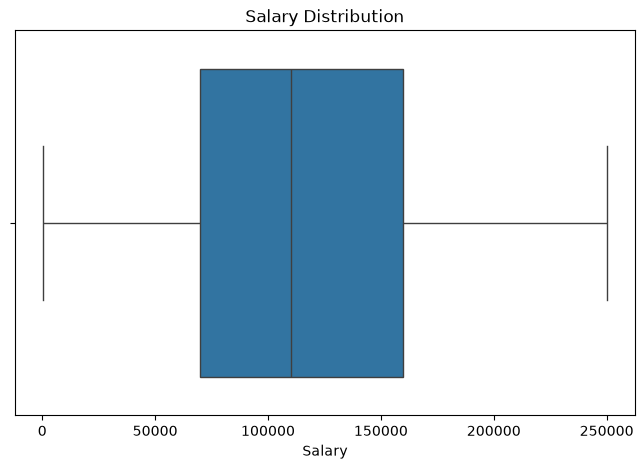

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Salary"])

plt.title("Salary Distribution")

plt.show()

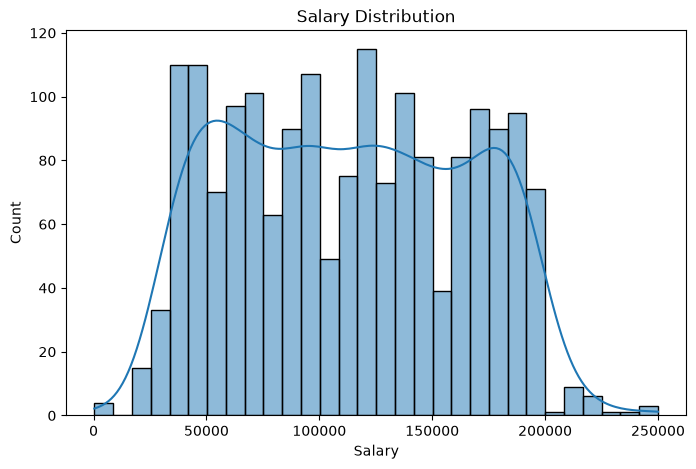

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["Salary"], bins=30, kde=True)

plt.title("Salary Distribution")

plt.show()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

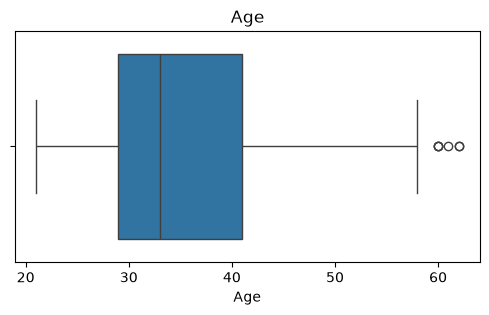

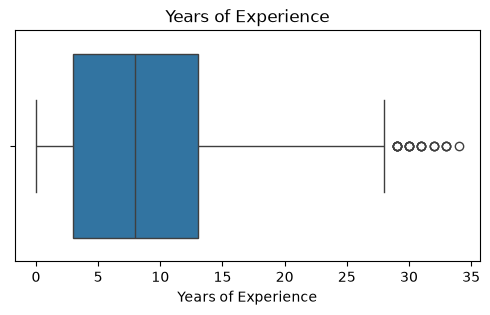

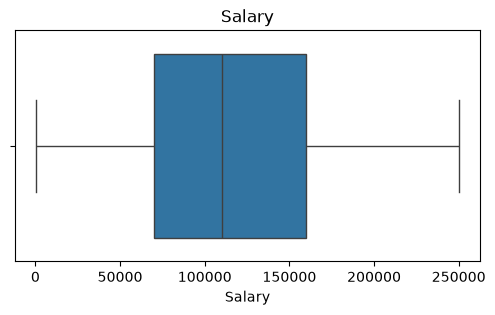

In [19]:
numerical_columns = ["Age", "Years of Experience", "Salary"]

for col in numerical_columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()
    

In [20]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers

In [21]:
age_outliers = detect_outliers_iqr(df, "Age")

age_outliers

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1211,61.0,Male,PhD,Software Engineer Manager,20.0,200000.0
1225,62.0,Male,PhD,Software Engineer Manager,19.0,200000.0
1236,62.0,Male,PhD,Software Engineer Manager,20.0,200000.0
1260,60.0,Male,PhD,Software Engineer Manager,18.0,195000.0
2396,60.0,Female,PhD,Software Engineer Manager,33.0,179180.0
2421,60.0,Female,PhD,Software Engineer Manager,34.0,188651.0


In [22]:
exp_outliers = detect_outliers_iqr(df, "Years of Experience")

exp_outliers

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
2378,53.0,Other,High School,Senior Project Engineer,31.0,166109.0
2387,57.0,Female,PhD,Full Stack Engineer,30.0,121450.0
2396,60.0,Female,PhD,Software Engineer Manager,33.0,179180.0
2401,57.0,Female,PhD,Software Engineer Manager,33.0,191790.0
2421,60.0,Female,PhD,Software Engineer Manager,34.0,188651.0
2435,57.0,Female,Master's Degree,Full Stack Engineer,33.0,188232.0
2541,55.0,Female,PhD,Software Engineer Manager,30.0,183138.0
2543,54.0,Male,Bachelor's Degree,Senior Project Engineer,29.0,191915.0
2554,54.0,Other,High School,Senior Software Engineer,29.0,158254.0
2557,52.0,Female,PhD,Software Engineer Manager,29.0,194214.0


In [23]:
print(len(age_outliers))
print(len(exp_outliers))

6
22


## Outliers Analysis

- Outliers were detected in Age and Years of Experience using the IQR method.
- After manual inspection, these values were found to be realistic.
- Decision:
    - Keep the outliers.
    - No rows were removed.

In [24]:
df.to_csv("../data/processed/cleaned_salary.csv", index=False)